> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API and this case's dependencies
%pip install -q coptpy matplotlib pandas


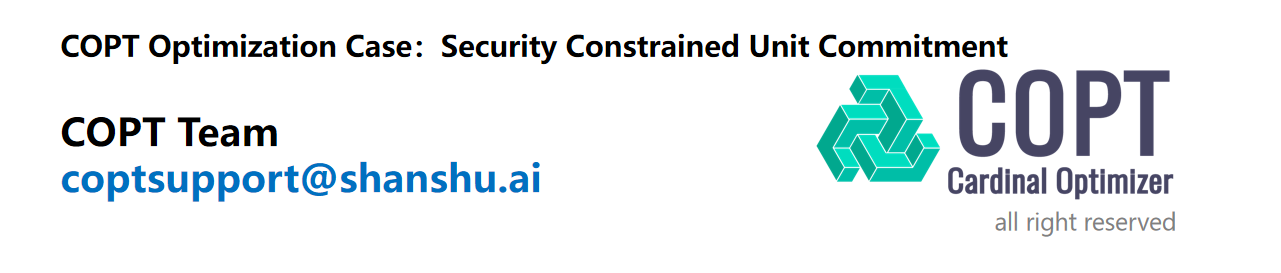

# Security Constrained Unit Commitment Code Implementation

## Steps to Model and Solve Security Constrained Unit Commitment Using COPT

1. **Import COPT-Python API** `coptpy`

2. **Add and Preprocess Model Data**
    - Import parameter list (including generator types, related parameters, and customer demand, etc.)

3. **Create the COPT Environment and COPT Model**

4. **Add three core components of COPT Model**
    - **Add Decision Variables**：
        - $\text{num\_gen}_{t,p} \in \mathbb{N}^+$: Number of operating units of type $t$ in period $p$ (units).
        - $\text{output}_{t,p} \in \mathbb{R}^+$: Total power output of units of type $t$ in period $p$ (MW).
        - $\text{num\_start}_{t,p} \in \mathbb{N}^+$: Number of units of type $t$ started up in period $p$ (units).
        - $\text{num\_stop}_{t,p} \in \mathbb{N}^+$: Number of units of type $t$ shut down in period $p$ (units).
    - **Set Objective Function**：Minimize the total cost of the three parts；
    - **Add Constraints**：
        - **Generator availability upper bound**
        - **Demand satisfaction**
        - **Minimum/maximum generation limits**
        - **Reserve requirement**
        - **Unit start/stop conservation**
        - **Ramp rate constraint**

5. **Solve**

6. View and interpret the **results**

## Import COPT-Python API

In [4]:
import coptpy as cp
from coptpy import COPT

import pandas as pd

import matplotlib.pyplot as plt

## Add Model Data

In [6]:
# Import number of generator types
num_types = 4
# Import number of time periods
num_periods = 7
# Import number of each generator already in operating state before the first time period
start0 = [2, 3, 1, 4]
# Add ramp-up rate
Rampup = [800, 400, 1500, 600]
# Add number of hours in different time periods
period_hours = [6, 2, 2, 3, 5, 4, 2]
# Add number of different type generators
generators = [20, 15, 8, 12]
# Add demand quantity in different time periods
demand = [25000, 45000, 49000, 55000, 48000, 62000, 30000]
# Add minimum power generation of generators
min_load = [600, 900, 1200, 800]
# Add maximum power generation of generators
max_load = [1500, 2200, 5000, 1800]
# Add minimum operating cost
base_cost = [1800, 3000, 4500, 2000]
# Add excess cost
run_over_cost = [1.8, 1.5, 3.5, 2.2]
# Add startup cost
start_up_cost = [3000, 1500, 800, 2500]


## Create the COPT Environment and COPT Model

In [8]:
env = cp.Envr()
model = env.createModel()

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## Add three core components of COPT Model
### Add Decision Variables
- $\text{num\_gen}_{t,p} \in \mathbb{N}^+$: Number of operating units of type $t$ in period $p$ (units).
- $\text{output}_{t,p} \in \mathbb{R}^+$: Total power output of units of type $t$ in period $p$ (MW).
- $\text{num\_start}_{t,p} \in \mathbb{N}^+$: Number of units of type $t$ started up in period $p$ (units).
- $\text{num\_stop}_{t,p} \in \mathbb{N}^+$: Number of units of type $t$ shut down in period $p$ (units).

In [10]:
num_gen = model.addVars(num_types, num_periods, vtype=COPT.INTEGER, nameprefix="num_gen")
num_start = model.addVars(num_types, num_periods, vtype=COPT.INTEGER, nameprefix="num_start")
num_stop = model.addVars(num_types, num_periods, vtype=COPT.INTEGER, nameprefix="num_stop")
output = model.addVars(num_types, num_periods, vtype=COPT.CONTINUOUS, nameprefix="output")

## Objective Function
**Minimize Total Cost**: Minimize total generation cost while meeting electricity demand in each time period.  
**Total cost components**: Running cost + Excess cost + Startup cost

$$
\begin{equation}
    \text{Minimize} \quad Z_{on} + Z_{extra} + Z_{startup}
\end{equation}
$$

- Running cost:
$$
\begin{equation}
    Z_{on} = \sum_{(t,p) \in \text{Types} \times \text{Periods}} \text{period\_hours}_p \times \text{base\_cost}_t \times \text{num\_gen}_{t,p}
\end{equation}
$$

- Excess cost:
$$
\begin{equation}
    Z_{extra} = \sum_{(t,p) \in \text{Types} \times \text{Periods}} \text{run\_over\_cost}_t \times (\text{output}_{t,p} - \text{min\_load}_t)
\end{equation}
$$

- Startup cost:
$$
\begin{equation}
    Z_{startup} = \sum_{(t,p) \in \text{Types} \times \text{Periods}} \text{start\_up\_cost}_t \times \text{num\_start}_{t,p}
\end{equation}
$$

In [12]:
active = cp.quicksum(base_cost[type]*period_hours[period]*num_gen[type,period]
                    for type in range(num_types) for period in range(num_periods))

per_mw = cp.quicksum(run_over_cost[type]*period_hours[period]*(output[type,period] - min_load[type]*num_gen[type,period])
                       for type in range(num_types) for period in range(num_periods))

startup_obj = cp.quicksum(start_up_cost[type]*num_start[type,period]
                         for type in range(num_types) for period in range(num_periods))

model.setObjective(active + per_mw + startup_obj, sense=COPT.MINIMIZE)

### Add Constraints
1. **Generator availability upper bound**:
$$
\begin{equation}
    \text{num\_gen}_{t,p} \leq \text{total\_generators}_t \quad \forall (t,p) \in \text{Types} \times \text{Periods}
\end{equation}
$$

In [14]:
numgen = model.addConstrs(num_gen[type, period] <= generators[type]
                         for type in range(num_types) for period in range(num_periods))


2. **Demand satisfaction**: The total power output from all generator types must satisfy the expected demand in each period $p$.
$$
\begin{equation}
    \sum_{t \in \text{Types}} \text{output}_{t,p} \geq \text{demand}_p \quad \forall p \in \text{Periods}
\end{equation}
$$

In [16]:
meet_demand = model.addConstrs(cp.quicksum(output[type, period] for type in range(num_types)) >= demand[period]
                               for period in range(num_periods))


3. **Minimum/maximum generation limits**: Power output must respect the minimum and maximum output limits of generators.
$$
\begin{equation}
    \text{output}_{t,p} \geq \text{min\_load}_t \times \text{num\_gen}_{t,p} \quad \forall (t,p) \in \text{Types} \times \text{Periods}
\end{equation}
$$

$$
\begin{equation}
    \text{output}_{t,p} \leq \text{max\_load}_t \times \text{num\_gen}_{t,p} \quad \forall (t,p) \in \text{Types} \times \text{Periods}
\end{equation}
$$

In [18]:
min_output = model.addConstrs((output[type, period] >= min_load[type] * num_gen[type, period])
                              for type in range(num_types) for period in range(num_periods))

max_output = model.addConstrs((output[type, period] <= max_load[type] * num_gen[type, period])
                              for type in range(num_types) for period in range(num_periods))

4. **Reserve requirement**: The chosen set of generators must be able to generate at least 135% of expected demand.
$$
\begin{equation}
    \sum_{t \in \text{Types}} \text{max\_load}_t \times \text{num\_gen}_{t,p} \geq 1.35 \times \text{demand}_p \quad \forall p \in \text{Periods}
\end{equation}
$$

In [20]:
reserve = model.addConstrs(cp.quicksum(max_load[type]*num_gen[type, period] for type in range(num_types)) 
                           >= 1.15*demand[period]
                           for period in range(num_periods))


5. **Unit start/stop conservation**: Relationship between running units and startup/shutdown units.
$$
\begin{equation}
    \text{num\_gen}_{t,p} = \text{num\_gen}_{t,p-1} + \text{num\_start}_{t,p} - \text{num\_stop}_{t,p} \quad \forall (t,p) \in \text{Types} \times \text{Periods}
\end{equation}
$$


In [22]:
startup0 = model.addConstrs((num_gen[type,0] == start0[type] + num_start[type,0] - num_stop[type,0])
                             for type in range(num_types))

startup = model.addConstrs((num_gen[type,period] == num_gen[type,period-1] + num_start[type,period] - num_stop[type, period])
                            for type in range(num_types) for period in range(1,num_periods))

6. **Ramp rate constraint**: Power changes between adjacent periods cannot be too abrupt to avoid mechanical issues (here, total power changes are directly considered).
$$
\begin{equation}
    \text{output}_{t,p} - \text{output}_{t,p-1} \leq \text{RampUp}_t \quad \forall (t,p) \in \text{Types} \times \text{Periods}
\end{equation}
$$

In [24]:
changing_speed = model.addConstrs(output[type, period] - output[type, period - 1] <= Rampup[type]
                                  for type in range(num_types) for period in range(1, num_periods))


7. **Minimum up/down time**: Once a unit is started, it must stay on for a certain time before shutting down; similarly, after shutting down, it must remain off for a while before starting again, to prevent mechanical wear. In this model, due to discretization of time periods, it only requires that units are not both started and shut down in the same period; no additional constraints are imposed on adjacent periods.
$$
\begin{equation}
    \text{generators}_{t} \geq \text{num\_start}_{t,p} + \text{num\_stop}_{t,p} \quad \forall (t,p) \in \text{Types} \times \text{Periods}
\end{equation}
$$

In [26]:
minimum_status_changing = model.addConstrs(generators[type] >= num_start[type, period] + num_stop[type, period]
                                           for type in range(num_types) for period in range(1, num_periods))

## Solve

In [28]:
model.solve()

Model fingerprint: 3e102a9b

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    174 rows, 112 columns and 400 non-zero elements
    84 integers

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    122 rows, 84 columns and 296 non-zero elements
    56 integers

Problem info:
    Range of matrix coefficients:    [1e+00,5e+03]
    Range of rhs coefficients:       [1e+00,7e+04]
    Range of bound coefficients:     [7e+00,4e+04]
    Range of cost coefficients:      [3e+00,8e+03]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0 -1.272000e+04            --     Inf  0.04s
H        0         1      --      

## Retrieve Results
### Show the number of operating units at different time periods
Each row represents the number of operating units of a certain type of generator set in different time periods, while each column indicates the number of operating units of various generator sets within that specific time period.

,0,1,2,3,4,5,6
Type0,7.0,8.0,8.0,9.0,9.0,10.0,1.0
Type1,14.0,15.0,15.0,15.0,15.0,15.0,11.0
Type2,0.0,0.0,1.0,2.0,1.0,3.0,0.0
Type3,4.0,4.0,4.0,5.0,5.0,5.0,5.0


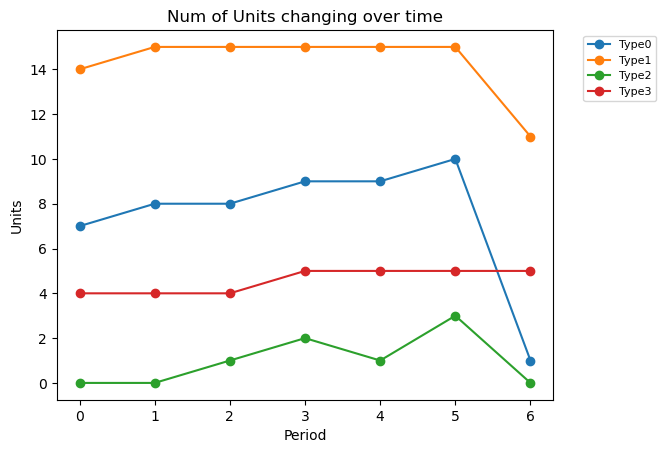

In [30]:
rows = ["Type" + str(t) for t in range(num_types)]
units = pd.DataFrame(columns=range(num_periods), index=rows, data=0.0)

for t in range(num_types):
    for p in range(num_periods):
        units.loc["Type"+str(t), p] = num_gen[t,p].x

display(units)

for idx, row in units.iterrows():
    y_values = row.values.astype(float)
    plt.plot(range(num_periods), y_values, marker='o', label=idx, linewidth=1.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.title("Num of Units changing over time")
plt.xlabel("Period")
plt.ylabel("Units")
plt.show()


In [31]:
starts = pd.DataFrame(columns=range(num_periods), index=rows, data=0.0)

for t in range(num_types):
    for p in range(num_periods):
        starts.loc["Type"+str(t), p] = int(num_start[t,p].x)
starts

,0,1,2,3,4,5,6
Type0,5.0,1.0,0.0,0.0,0.0,0.0,0.0
Type1,11.0,1.0,0.0,0.0,0.0,0.0,0.0
Type2,0.0,0.0,1.0,1.0,0.0,2.0,0.0
Type3,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [32]:
ends = pd.DataFrame(columns=range(num_periods), index=rows, data=0.0)

for t in range(num_types):
    for p in range(num_periods):
        ends.loc["Type"+str(t), p] = int(num_stop[t,p].x)
ends

,0,1,2,3,4,5,6
Type0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
Type1,0.0,0.0,0.0,0.0,0.0,0.0,4.0
Type2,1.0,0.0,0.0,0.0,1.0,0.0,3.0
Type3,0.0,0.0,0.0,0.0,0.0,0.0,0.0
